## 1. Análise Exploratória dos Dados (EDA)

Carregamento do dataset, visualização das primeiras linhas e realização de análise gráfica para entender melhor os dados.

### Documentação da Base de Dados

- **Nome da base:** IMDb Movies & Series (adaptada)
- **Fonte:** [Kaggle](https://www.kaggle.com/datasets/mazenramadan/imdb-most-popular-films-and-series/data)
- **Descrição das variáveis principais:**
    - `Name`: Título do filme ou série
    - `Date`: Ano de lançamento
    - `Rate`: Nota média dos usuários
    - `Votes`: Número de votos recebidos
    - `Genre`: Gênero principal
    - `Duration`: Duração em minutos
    - `Type`: Tipo (Movie ou Series)
- **Objetivo:** Prever automaticamente se um filme será "Bem avaliado" (nota >= 7) ou "Mal avaliado" (nota < 7).

A base foi filtrada para considerar apenas filmes, removendo séries e registros duplicados, garantindo consistência para o treinamento dos modelos.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# estilo dos graficos
sns.set(style="whitegrid")

# carregamento do dataset
caminho_dataset = 'dataset/imdb.csv'
df_original = pd.read_csv(caminho_dataset)
df = df_original.copy()

# exemplo das primeirsa linhas do dataset
df.head()

,Name,Date,Rate,Votes,Genre,Duration,Type,Certificate,Episodes,Nudity,Violence,Profanity,Alcohol,Frightening
0,No Time to Die,2021,7.6,"107,163","Action, Adventure, Thriller",163.0,Film,PG-13,-,Mild,Moderate,Mild,Mild,Moderate
1,The Guilty,2021,6.3,"64,375","Crime, Drama, Thriller",90.0,Film,R,-,NaN,NaN,Severe,NaN,Moderate
2,The Many Saints of Newark,2021,6.4,"27,145","Crime, Drama",120.0,Film,R,-,Moderate,Severe,Severe,Moderate,Moderate
3,Venom: Let There Be Carnage,2021,6.4,"30,443","Action, Adventure, Sci-Fi",97.0,Film,PG-13,-,NaN,Moderate,Moderate,Mild,Moderate
4,Dune,2021,8.3,"84,636","Action, Adventure, Drama",155.0,Film,PG-13,-,NaN,Moderate,NaN,Mild,Moderate


In [63]:
import numpy as np

tipos_obras = df_original['Type'].unique()
print("Tipos de obras no dataset:", tipos_obras)

# mudando todas as series para NaN para ignorar no dataset
mascara_series = df_original['Type'].str.contains('Series', case=False, na=False)
df_original.loc[mascara_series, 'Duration'] = np.nan

# verificando quantidade de series com o print
print(f"Quantidade de filmes/séries sem duração agora: {df_original['Duration'].isna().sum()}")

Tipos de obras no dataset: <StringArray>
['Film', 'Series']
Length: 2, dtype: str
Quantidade de filmes/séries sem duração agora: 1542


In [54]:
# Remover registros duplicados com mesmo Name, Date e Rate
antes = len(df_original)
df_original = df_original.drop_duplicates(subset=['Name', 'Date', 'Rate'], keep='first')
depois = len(df_original)
print(f"Registros duplicados removidos: {antes - depois}")

Registros duplicados removidos: 1150


### Gráfico 1: Distribuição das Notas dos Filmes

Gráfico exibindo distribuição das notas dos filmes.

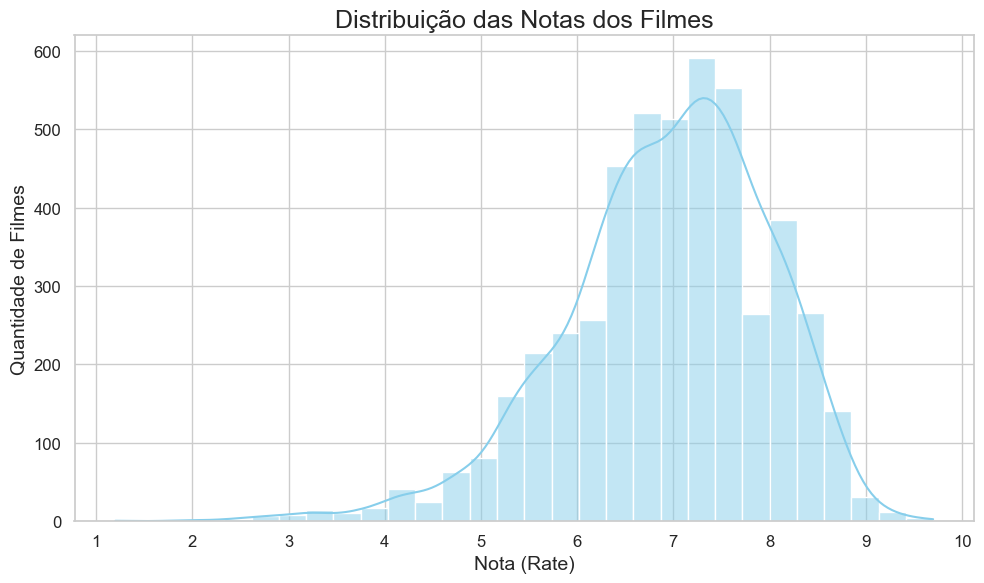

In [ ]:
# grafico geral de distribuicao de notas
rate_num = pd.to_numeric(df_original['Rate'], errors='coerce')
plt.figure(figsize=(10, 6))
sns.histplot(rate_num, bins=30, kde=True, color='skyblue')
plt.title('Distribuição das Notas dos Filmes', fontsize=18)
plt.xlabel('Nota (Rate)', fontsize=14)
plt.ylabel('Quantidade de Filmes', fontsize=14)
plt.xticks(range(1, 11), fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

### Gráfico 2: Relação entre Número de Votos e Nota

Agora, vamos explorar se existe alguma relação entre o número de votos que um filme recebe e sua nota.

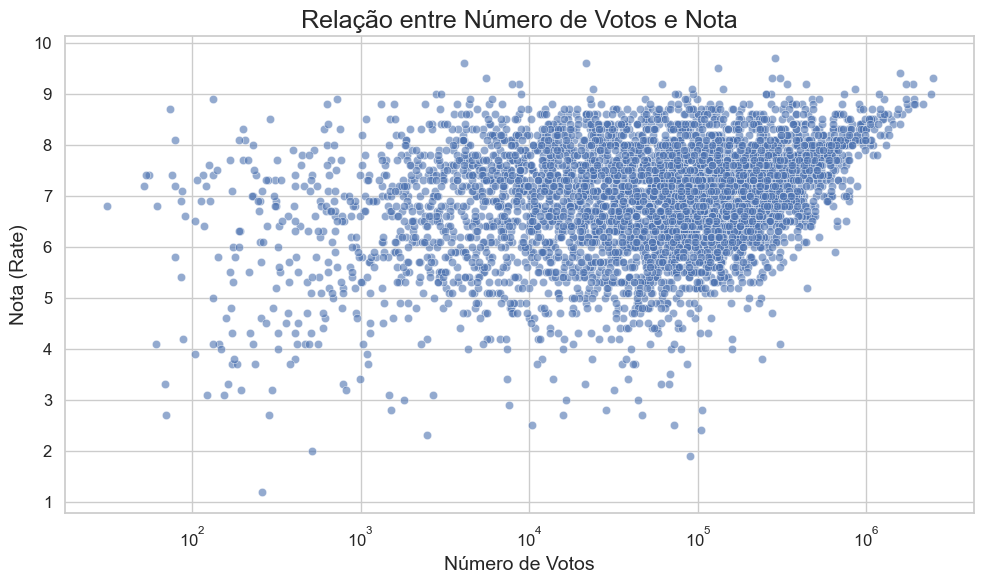

In [ ]:
# passando votes para valor numerico
votes_temp = pd.to_numeric(df_original['Votes'].astype(str).str.replace(',', ''), errors='coerce')
rate_temp = pd.to_numeric(df_original['Rate'], errors='coerce')

# removendo linhas com valores nao numericos
mask_validos = votes_temp.notna() & rate_temp.notna()
votes_temp = votes_temp[mask_validos]
rate_temp = rate_temp[mask_validos]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=votes_temp, y=rate_temp, alpha=0.6)
plt.title('Relação entre Número de Votos e Nota', fontsize=18)
plt.xlabel('Número de Votos', fontsize=14)
plt.ylabel('Nota (Rate)', fontsize=14)
plt.xscale('log')  # Escala log para melhor visualização
plt.xticks(fontsize=12)
plt.yticks(range(1, 11), fontsize=12)
plt.tight_layout()
plt.show()

### Gráfico 3: Duração dos Filmes por Faixa de Nota

Vamos analisar como a duração dos filmes varia de acordo com a faixa de nota recebida.

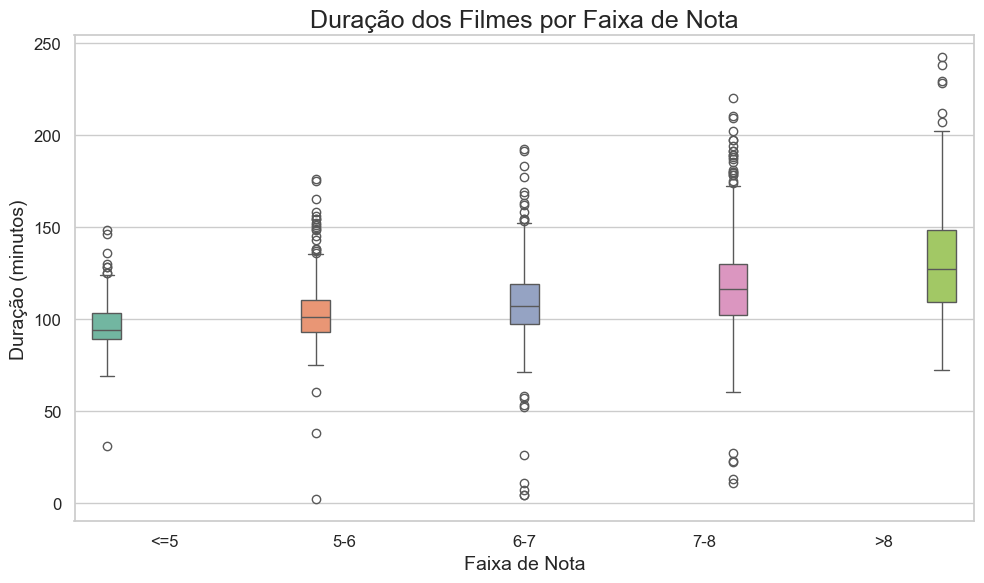

In [ ]:
bins = [0, 5, 6, 7, 8, 10]
labels = ['<=5', '5-6', '6-7', '7-8', '>8']
df_original['Faixa_Nota'] = pd.cut(pd.to_numeric(df_original['Rate'], errors='coerce'), bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Faixa_Nota', y='Duration', data=df_original, palette='Set2', hue='Faixa_Nota', legend=False)
plt.title('Duração dos Filmes por Faixa de Nota', fontsize=18)
plt.xlabel('Faixa de Nota', fontsize=14)
plt.ylabel('Duração (minutos)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

## 2. Pré-processamento dos Dados

Agora, vamos preparar os dados para o treinamento dos modelos de Machine Learning. Isso inclui conversão de tipos, criação da variável alvo, seleção de features e divisão dos dados.

In [58]:
# Conversão da coluna Rate para numérico
# Remoção das vírgulas da coluna Votes e conversão para numérico, tratando erros
# Criação da coluna alvo target
# Seleção das features e remoção de NaNs
# Divisão em treino e teste

from sklearn.model_selection import train_test_split

# Rate para float
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

# Votes para float, tratando valores não numéricos
votes_numeric = pd.to_numeric(df['Votes'].str.replace(',', ''), errors='coerce')
df['Votes'] = votes_numeric

# Coluna alvo: 1 se Rate >= 7, senão 0
df['target'] = (df['Rate'] >= 7).astype(int)

# Seleção das features
X = df[['Date', 'Votes', 'Duration']].copy()
X['Date'] = pd.to_numeric(X['Date'], errors='coerce')  # Garante que Date é numérico
y = df['target']

# Remover linhas com valores nulos
mask_valid = X.notna().all(axis=1)
X = X[mask_valid]
y = y[mask_valid]

# Divisão em treino e teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Visualizar as primeiras linhas das features pré-processadas
X_train.head()

,Date,Votes,Duration
2857,2021,18244.0,96.0
2956,2004,185552.0,127.0
1906,2020,86317.0,123.0
5091,2016,170350.0,107.0
1621,2019,48427.0,90.0


## 3. Treinamento dos Modelos de Machine Learning

Nesta etapa, vamos treinar quatro algoritmos diferentes: Árvore de Decisão, Regressão Logística, K-Nearest Neighbors (KNN) e Naive Bayes (GaussianNB).

In [59]:
# Importação dos modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Instanciando os modelos
modelos = {
    'Árvore de Decisão': DecisionTreeClassifier(random_state=42),
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

# Treinando os modelos
treinados = {}
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    treinados[nome] = modelo

print("Modelos treinados com sucesso!")

Modelos treinados com sucesso!


## 4. Avaliação dos Modelos

Vamos avaliar o desempenho de cada modelo utilizando a matriz de confusão e o classification report, que traz métricas como acurácia, precisão, recall e F1-score.

In [60]:
from sklearn.metrics import confusion_matrix, classification_report

for nome, modelo in treinados.items():
    print(f"\nModelo: {nome}")
    y_pred = modelo.predict(X_test)
    print("Matriz de Confusão:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=3))


Modelo: Árvore de Decisão
Matriz de Confusão:
[[446 124]
 [127 472]]

Classification Report:
              precision    recall  f1-score   support

           0      0.778     0.782     0.780       570
           1      0.792     0.788     0.790       599

    accuracy                          0.785      1169
   macro avg      0.785     0.785     0.785      1169
weighted avg      0.785     0.785     0.785      1169


Modelo: Regressão Logística
Matriz de Confusão:
[[414 156]
 [216 383]]

Classification Report:
              precision    recall  f1-score   support

           0      0.657     0.726     0.690       570
           1      0.711     0.639     0.673       599

    accuracy                          0.682      1169
   macro avg      0.684     0.683     0.682      1169
weighted avg      0.685     0.682     0.681      1169


Modelo: KNN
Matriz de Confusão:
[[356 214]
 [245 354]]

Classification Report:
              precision    recall  f1-score   support

           0      0.5

## 5. Função de Predição para Novos Filmes

Agora, vamos criar uma função que recebe os dados de um novo filme (Ano, Votos, Duração) e utiliza o melhor modelo treinado para prever se o filme será "Bem Avaliado" (1) ou não (0).

In [61]:
# Função de predição usando o melhor modelo (exemplo: Regressão Logística)
# Substitua pelo modelo de melhor desempenho após avaliação
melhor_modelo = treinados['Regressão Logística']

def prever_sucesso_filme(ano, votos, duracao):
    """
    Recebe ano (int), votos (int ou float), duração (float) e retorna 1 (bem avaliado) ou 0 (não).
    """
    entrada = pd.DataFrame({
        'Date': [ano],
        'Votes': [votos],
        'Duration': [duracao]
    })
    return int(melhor_modelo.predict(entrada)[0])

# Exemplo de uso da função:
exemplo = prever_sucesso_filme(2022, 15000, 120.0)
print(f"Exemplo de predição para filme fictício: {exemplo} (1 = Bem Avaliado, 0 = Não)")

Exemplo de predição para filme fictício: 0 (1 = Bem Avaliado, 0 = Não)


---

## Conclusão

Neste notebook, seguimos todas as etapas fundamentais de um projeto de Machine Learning:

- Realizamos uma análise exploratória dos dados (EDA) com visualizações.
- Pré-processamos o dataset, criando a variável alvo e selecionando as features.
- Treinamos quatro modelos de classificação binária.
- Avaliamos o desempenho de cada modelo com métricas apropriadas.
- Criamos uma função de predição para novos dados.

Esse fluxo é típico em projetos reais e acadêmicos, garantindo reprodutibilidade e clareza.